<a href="https://colab.research.google.com/github/ChristianAgyapong/Medgemma/blob/main/TASK_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, classification_report, confusion_matrix
import seaborn as sns

In [ ]:
cancer = load_breast_cancer(as_frame=True)
df = cancer.frame

print("Shape:", df.shape)
print("\nTarget classes:", cancer.target_names)  # ['malignant' 0, 'benign' 1]

X = df.drop('target', axis=1)
y = df['target']

# Scale features (very important for SVM!)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape[0], "| Test:", X_test.shape[0])

Shape: (569, 31)

Target classes: ['malignant' 'benign']
Train: 426 | Test: 143


In [ ]:
kernels = ['linear', 'rbf']  # we'll compare these two
models = {}
results = []

for kernel in kernels:
    svm = SVC(kernel=kernel, probability=True, random_state=42)
    svm.fit(X_train, y_train)

    y_pred = svm.predict(X_test)
    y_proba = svm.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)

    models[kernel] = svm
    results.append({
        'Kernel': kernel,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'AUC': auc
    })

# Show comparison table
results_df = pd.DataFrame(results).round(4)
print("\nPerformance Comparison:")
print(results_df)


Performance Comparison:
   Kernel  Accuracy  Precision  Recall     AUC
0  linear     0.986     0.9889  0.9889  0.9973
1     rbf     0.979     0.9888  0.9778  0.9969



Best Model (RBF kernel) Report:
              precision    recall  f1-score   support

   malignant       0.96      0.98      0.97        53
      benign       0.99      0.98      0.98        90

    accuracy                           0.98       143
   macro avg       0.98      0.98      0.98       143
weighted avg       0.98      0.98      0.98       143



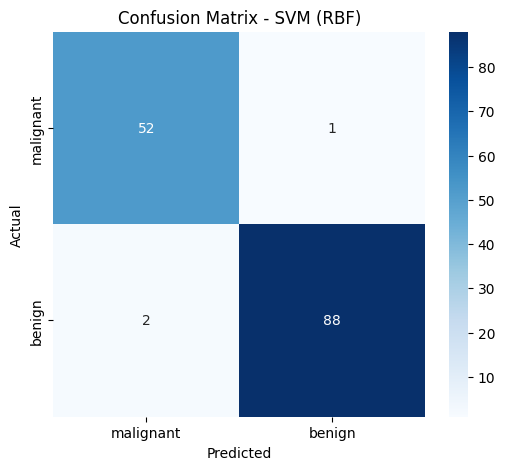

AUC: 0.9969


In [ ]:
# Pick the best (or compare both — here we take RBF as example)
best_kernel = 'rbf'  # change to 'linear' if you prefer
best_svm = models[best_kernel]

y_pred_best = best_svm.predict(X_test)
y_proba_best = best_svm.predict_proba(X_test)[:, 1]

print(f"\nBest Model ({best_kernel.upper()} kernel) Report:")
print(classification_report(y_test, y_pred_best, target_names=cancer.target_names))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=cancer.target_names,
            yticklabels=cancer.target_names)
plt.title(f'Confusion Matrix - SVM ({best_kernel.upper()})')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print(f"AUC: {roc_auc_score(y_test, y_proba_best):.4f}")

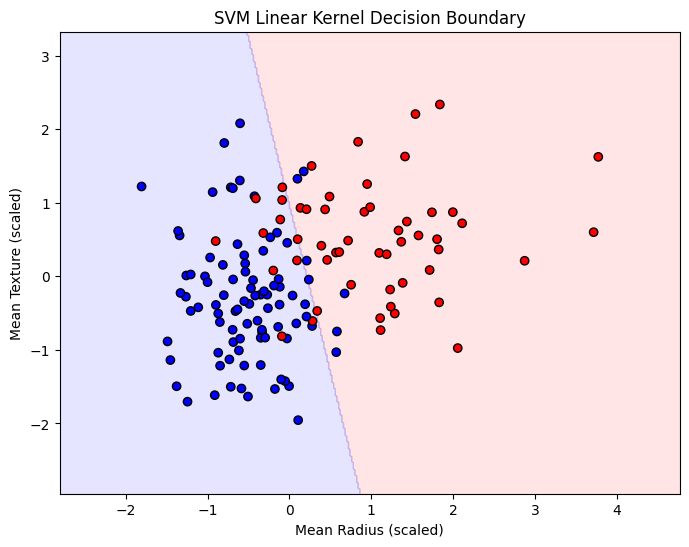

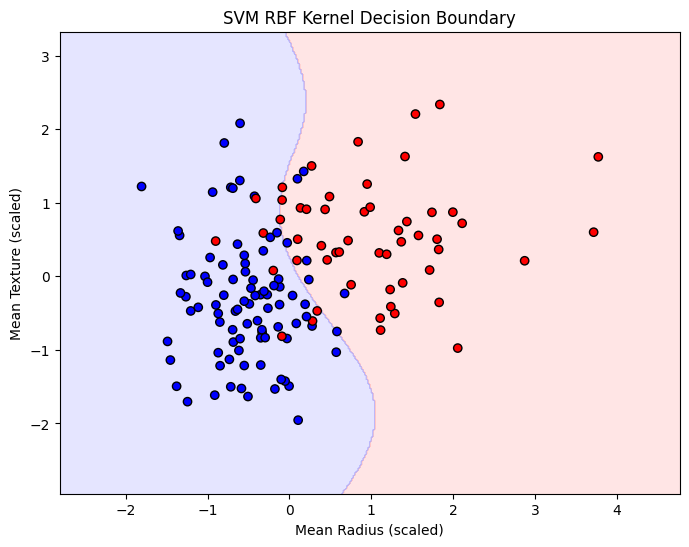

In [ ]:
# Use only 2 features for plotting
X_2d = X_scaled[:, :2]  # mean radius & mean texture
X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(
    X_2d, y, test_size=0.25, random_state=42, stratify=y
)

# Train SVMs on 2D data
svm_linear_2d = SVC(kernel='linear', random_state=42).fit(X_train_2d, y_train_2d)
svm_rbf_2d    = SVC(kernel='rbf', random_state=42).fit(X_train_2d, y_train_2d)

# Plot function
def plot_decision_boundary(clf, X, y, title):
    h = 0.02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(8,6))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=ListedColormap(['#FFAAAA', '#AAAAFF']))
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap=ListedColormap(['red', 'blue']))
    plt.xlabel('Mean Radius (scaled)')
    plt.ylabel('Mean Texture (scaled)')
    plt.title(title)
    plt.show()

# Visualize both
plot_decision_boundary(svm_linear_2d, X_test_2d, y_test_2d, "SVM Linear Kernel Decision Boundary")
plot_decision_boundary(svm_rbf_2d,    X_test_2d, y_test_2d, "SVM RBF Kernel Decision Boundary")